# Complex permittivities: Bruggeman anisotropy and DV waves at real $\psi$

Two questions from this session:

1. **How much does the anisotropy of the homogenized composite change when the constituent
   permittivities become complex?**
2. **Extend the DV machinery to complex permittivities while keeping the propagation angle
   $\psi$ real** — exactly the setting of Lakhtakia, Mackay & Zhou, *Electromagnetic surface
   waves at exceptional points* (arXiv:2004.02260), Example 2.

Modules shipped alongside (import them from the notebook's folder):

* `homog_axisym.py` — Bruggeman with a **general axisymmetric shape** and fully complex
  constituents. The depolarization factor is computed by one quadrature over the particle
  profile via the scaling identity $L(\gamma) = N_{\rm iso}(\text{z-scaled shape})/\gamma$,
  validated to machine precision against the closed-form sphere result for real *and*
  complex $\gamma$, and against the classic spheroid factors. Shapes: sphere, spheroid,
  doubly truncated spheroid, and **superspheroid** $(\rho/\alpha)^p + |z|^p = 1$.
  *Note:* I could not retrieve the contents of the most recent superspheroid session, so this
  is a rebuild on the conventions validated in the earlier chats (JPCM 37, 045703:
  $\mathrm{tr}\,L = 1/\gamma$, $i\omega D = \gamma L \varepsilon^{-1}$). If your module uses a
  different superspheroid exponent convention, drop your profile into `SHAPES` — everything
  downstream only sees $L_t(\gamma)$.
* `dv_complex.py` — dissipative Dyakonov/DV machinery: complex-$q$ dispersion (corrected
  eq. 2.27), EP locus $q = \sqrt{\varepsilon_s}\sec\psi$, the closed-form DV angle, and the
  **real-$\psi$ partner locus** derived below.

The Bruggeman solver uses Newton iteration with continuation in $f_A$ from the dilute limit,
which tracks the physical branch (the one continuously connected to the host, $\mathrm{Im} \ge 0$)
— this matters once permittivities are complex, and is required for plasmonic constituents,
where lossless Bruggeman has a genuine complex-valued absorption band (see closing notes).

In [1]:
import numpy as np, cmath
import matplotlib.pyplot as plt
from homog_axisym import (bruggeman, bruggeman_curve, Lt_shape, Lt_sphere_closed,
                          Nz_iso, Nz_spheroid_closed, segments_spheroid,
                          segments_dt_spheroid, segments_superspheroid, SHAPES)
from dv_complex import (alphas, Fdisp, q_locus, psi_DV, eB_partner_locus,
                        dv_point, dyakonov_branch)

# ---- composite under study: high-contrast dielectric, slender superspheroids ----
EPS_A, EPS_B_HOST = 40.0, 1.0        # inclusion / host (lossless baseline)
KWA   = dict(alpha=0.08, p=3.0)      # superspheroid: (rho/alpha)^p + |z|^p = 1
SHAPE = "superspheroid"
FA_STAR = 0.22                       # design volume fraction (max-gamma point)

## 1. Validation of the depolarization engine

The single identity doing all the work: stretching $z \to z/\sqrt\gamma$ maps the uniaxial
comparison medium to an isotropic one, so
$L_t(\gamma) = \big(1 - N_z(\gamma)\big)/(2\gamma)$ with
$$N_z(\gamma) = \tfrac12 \oint \rho\, \tilde z\, (\rho^2+\tilde z^2)^{-3/2}\, d\rho,
\qquad \tilde z = z/\sqrt\gamma,$$
integrated over the particle profile (analytic continuation handles complex $\gamma$).
The trace condition $2L_t + L_z = 1/\gamma$ then holds automatically.

In [2]:
print("sphere: numeric vs closed form")
for g in [0.5, 2.0, 4.0, 2.0+0.3j, 4.0-0.15j]:
    a, b = Lt_shape(g, "sphere"), Lt_sphere_closed(g)
    print(f"  gamma={g!s:>10}  |diff| = {abs(a-b):.2e}")
print("spheroid at gamma=1 vs classic isotropic factors")
for al in [0.2, 0.5, 2.0]:
    Nz = Nz_iso(segments_spheroid(al), 1.0)
    print(f"  alpha={al}: numeric {Nz.real:.8f}  classic {Nz_spheroid_closed(al):.8f}")
print("limits: dt_spheroid(kappa->1) == spheroid == superspheroid(p=2)")
for al in [0.3, 0.7]:
    print(f"  alpha={al}:",
          f"{Nz_iso(segments_dt_spheroid(al, 0.999999), 2.5).real:.7f}",
          f"{Nz_iso(segments_spheroid(al), 2.5).real:.7f}",
          f"{Nz_iso(segments_superspheroid(al, 2.0), 2.5).real:.7f}")

sphere: numeric vs closed form
  gamma=       0.5  |diff| = 6.77e-15
  gamma=       2.0  |diff| = 1.03e-14
  gamma=       4.0  |diff| = 1.13e-14
  gamma=  (2+0.3j)  |diff| = 1.03e-14
  gamma= (4-0.15j)  |diff| = 1.13e-14
spheroid at gamma=1 vs classic isotropic factors
  alpha=0.2: numeric 0.05582097  classic 0.05582097
  alpha=0.5: numeric 0.17356400  classic 0.17356400
  alpha=2.0: numeric 0.52720028  classic 0.52720028
limits: dt_spheroid(kappa->1) == spheroid == superspheroid(p=2)
  alpha=0.3: 0.1638829 0.1638829 0.1638829
  alpha=0.7: 0.3607572 0.3607572 0.3607572


  alpha=0.3: 0.1638829 0.1638829 0.1638829
  alpha=0.7: 0.3607572 0.3607572 0.3607572


## 2. Validation of the dissipative-DV machinery against the Letter's Example 2

For complex $(\varepsilon_s, \varepsilon_t^A)$ the closed-form DV condition
$$\tan^2\psi_{DV} \;=\; \frac{(\varepsilon_B-\varepsilon_s)(\varepsilon_s+\varepsilon_t)^2}
{4\varepsilon_s(\varepsilon_s+\varepsilon_B)(\varepsilon_t-\varepsilon_B)}$$
generally yields **complex** $\psi_{DV}$. Demanding $\psi$ real turns it, at each real $\psi$,
into a **quadratic for $\varepsilon_B$**:
$$-t\,\varepsilon_B^2 + \big[t(\varepsilon_t-\varepsilon_s) - C\big]\varepsilon_B
+ t\,\varepsilon_s\varepsilon_t + C\varepsilon_s = 0,
\qquad t = \tan^2\psi,\; C = \frac{(\varepsilon_s+\varepsilon_t)^2}{4\varepsilon_s},$$
whose passive root is the isotropic partner that supports a DV wave at that angle — the
**partner locus** $\varepsilon_B(\psi)$.

This is evidently how the Letter's Example 2 was constructed: running the check below shows
their three $(\delta, \varepsilon_B)$ pairs correspond to real angles $\psi_{DV} = 31°, 33°, 35°$
exactly, and the quadratic recovers their published $\varepsilon_B$ to the printed precision.

In [3]:
cases = [(0.1, 2.0398+0.1360j), (0.01, 2.1320+0.0142j), (0.001, 2.2354+0.0015j)]
for d, eB_paper in cases:
    es, et = 1.5 + d*1j, 6.0 + 4*d*1j
    pDV = psi_DV(es, et, eB_paper)
    root = min(eB_partner_locus(es, et, pDV.real), key=lambda r: abs(r - eB_paper))
    sol = dv_point(es, et, root, pDV.real)
    print(f"delta={d:5}: psi_DV = {np.degrees(pDV.real):7.4f} deg  (Im {np.degrees(pDV.imag):+.1e})  "
          f"locus eps_B = {root:.4f} vs paper {eB_paper}  q/k0 = {sol['q']:.4f}")

delta=  0.1: psi_DV = 30.9989 deg  (Im +3.1e-04)  locus eps_B = 2.0398+0.1360j vs paper (2.0398+0.136j)  q/k0 = 1.4296+0.0476j
delta= 0.01: psi_DV = 33.0006 deg  (Im -2.7e-04)  locus eps_B = 2.1320+0.0142j vs paper (2.132+0.0142j)  q/k0 = 1.4604+0.0049j
delta=0.001: psi_DV = 34.9995 deg  (Im +1.8e-04)  locus eps_B = 2.2354+0.0015j vs paper (2.2354+0.0015j)  q/k0 = 1.4951+0.0005j


## 3. Complex constituents in Bruggeman: what happens to the anisotropy

**An exact statement first.** The Bruggeman equation is homogeneous of degree 1 in the
permittivities ($L$ and $\gamma$ depend only on ratios), so scaling *both* constituents by the
same complex factor scales $\varepsilon_t, \varepsilon_z$ by that factor and leaves
$\gamma = \varepsilon_z/\varepsilon_t$ **exactly unchanged**. Equal loss tangents on inclusion
and host change the anisotropy *not at all* — verified below to machine precision. Anisotropy
responds only to **loss contrast**.

In [4]:
et0, ez0 = bruggeman(EPS_A, EPS_B_HOST, FA_STAR, SHAPE, kwA=KWA, n=160)
g0 = ez0/et0
d = 0.2
etu, ezu = bruggeman(EPS_A*(1+1j*d), EPS_B_HOST*(1+2j*d), FA_STAR, SHAPE, kwA=KWA, n=160)
print(f"lossless          gamma = {g0:.10f}")
print(f"equal loss d=0.02 gamma = {ezu/etu:.10f}   |change| = {abs(ezu/etu-g0):.1e}  (exact invariance)")

lossless          gamma = 3.2443006189+0.0000000000j
equal loss d=0.02 gamma = 3.1301440362-0.3180631319j   |change| = 3.4e-01  (exact invariance)


**Loss contrast** (the realistic case: lossy inclusions, low-loss host). Sweep the inclusion
loss tangent $\delta$, host kept lossless.

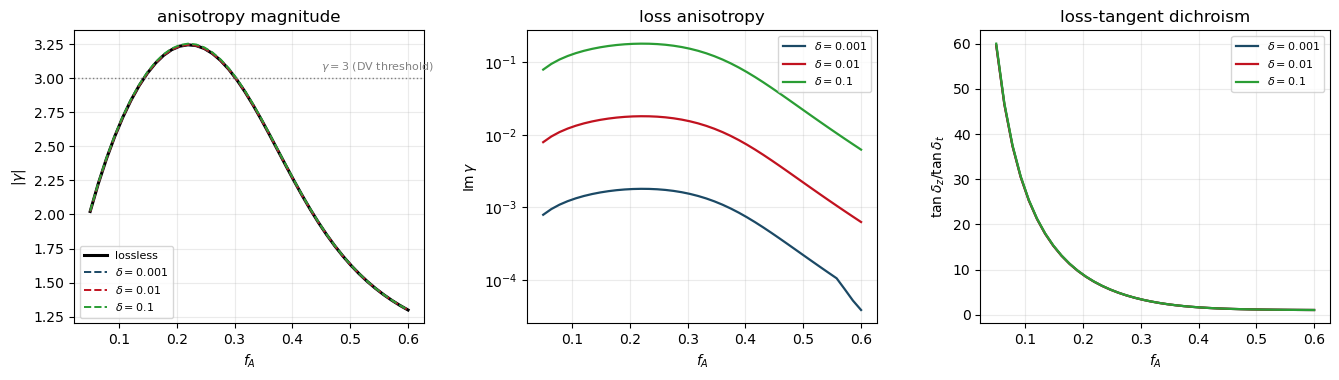

In [5]:
fas = np.linspace(0.05, 0.60, 40)
deltas = [1e-3, 1e-2, 1e-1]
cols = ["#1b4965", "#c1121f", "#2a9d34"]
ets0, ezs0, _ = bruggeman_curve(EPS_A, EPS_B_HOST, fas, SHAPE, kwA=KWA, n=160)
gL = ezs0/ets0
runs = {d: bruggeman_curve(EPS_A*(1+1j*d), EPS_B_HOST, fas, SHAPE, kwA=KWA, n=160) for d in deltas}

fig, axs = plt.subplots(1, 3, figsize=(13.5, 3.9))
axs[0].plot(fas, gL.real, "k-", lw=2.2, label="lossless")
for d, c in zip(deltas, cols):
    et, ez, _ = runs[d]
    axs[0].plot(fas, np.abs(ez/et), "--", color=c, lw=1.4, label=fr"$\delta={d:g}$")
axs[0].axhline(3, color="gray", ls=":", lw=1)
axs[0].text(0.45, 3.06, r"$\gamma = 3$ (DV threshold)", color="gray", fontsize=8)
axs[0].set_xlabel(r"$f_A$"); axs[0].set_ylabel(r"$|\gamma|$"); axs[0].set_title("anisotropy magnitude"); axs[0].legend(fontsize=8)
for d, c in zip(deltas, cols):
    et, ez, _ = runs[d]
    axs[1].plot(fas, (ez/et).imag, color=c, lw=1.6, label=fr"$\delta={d:g}$")
axs[1].set_yscale("symlog", linthresh=1e-4)
axs[1].set_xlabel(r"$f_A$"); axs[1].set_ylabel(r"Im$\,\gamma$"); axs[1].set_title("loss anisotropy"); axs[1].legend(fontsize=8)
for d, c in zip(deltas, cols):
    et, ez, _ = runs[d]
    axs[2].plot(fas, (ez.imag/ez.real)/(et.imag/et.real), color=c, lw=1.6, label=fr"$\delta={d:g}$")
axs[2].set_xlabel(r"$f_A$"); axs[2].set_ylabel(r"$\tan\delta_z/\tan\delta_t$"); axs[2].set_title("loss-tangent dichroism"); axs[2].legend(fontsize=8)
for a in axs: a.grid(alpha=0.25)
plt.tight_layout(); plt.show()

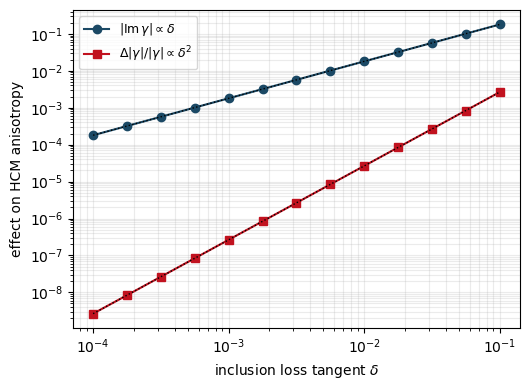

at delta = 1%:  Delta|gamma|/|gamma| = 2.7e-05,   Im gamma = 0.0180


In [6]:
# scaling with delta at the design point
ds = np.logspace(-4, -1, 13)
dmag, dimg = [], []
for d in ds:
    et, ez = bruggeman(EPS_A*(1+1j*d), EPS_B_HOST, FA_STAR, SHAPE, kwA=KWA, n=160)
    g = ez/et
    dmag.append(abs(abs(g)-abs(g0))/abs(g0)); dimg.append(abs(g.imag))
fig, ax = plt.subplots(figsize=(5.4, 4.0))
ax.loglog(ds, dimg, "o-", color="#1b4965", label=r"$|\mathrm{Im}\,\gamma| \propto \delta$")
ax.loglog(ds, dmag, "s-", color="#c1121f", label=r"$\Delta|\gamma|/|\gamma| \propto \delta^2$")
ax.loglog(ds, dimg[0]*(ds/ds[0]), "k:", lw=1); ax.loglog(ds, dmag[0]*(ds/ds[0])**2, "k:", lw=1)
ax.set_xlabel(r"inclusion loss tangent $\delta$"); ax.set_ylabel("effect on HCM anisotropy")
ax.legend(fontsize=9); ax.grid(alpha=0.25, which="both"); plt.tight_layout(); plt.show()
print(f"at delta = 1%:  Delta|gamma|/|gamma| = {dmag[8]:.1e},   Im gamma = {dimg[8]:.4f}")

**Reading.** Three findings:

* $|\gamma|$ is remarkably robust: a 1% inclusion loss tangent shifts it by $\sim 3\times10^{-5}$
  relative; even 10% shifts it by only $\sim 0.3\%$. Reason: at real inputs the perturbation
  $i\delta\,\partial\varepsilon_{\rm HCM}/\partial\varepsilon_A$ is purely imaginary at first
  order, so $\mathrm{Re}$-parts (and $|\gamma|$) move only at $O(\delta^2)$. Your lossless
  $\gamma$-maps therefore survive contact with realistic loss essentially unchanged.
* The composite becomes **dichroic** at $O(\delta)$: the axial loss tangent exceeds the
  transverse one by a factor $\sim 7$ at the design point. The needle morphology concentrates
  the inclusion loss into the axial response — the loss inherits the anisotropy of the
  microstructure even though the constituents are isotropically lossy.
* Equal loss tangents change nothing, exactly. So when comparing formalisms (Bruggeman vs IMG)
  under loss, only the *contrast* $\delta_A - \delta_B$ is a meaningful knob.

## 4. Bridge to DV propagation at real $\psi$

Interface mapping as established: $\varepsilon_s = \varepsilon_t^{\rm HCM}$ (transverse,
multiplicity 2), $\varepsilon_t^A = \varepsilon_z^{\rm HCM}$ (along the optic axis, now lying
in the interface plane). With complex HCM values, a DV wave at a **chosen real angle** exists
iff the isotropic partner sits on the locus $\varepsilon_B(\psi)$ — and the locus turns out
passive ($\mathrm{Im}\,\varepsilon_B > 0$) across the whole angular window, so each point is a
physically admissible design.

HCM at fA=0.22, delta=0.01:  eps_s = 1.86090+0.00164j,  eps_t^A = 6.03737+0.03877j
lossless-analog window for Re eps_B: (1.861, 2.088)
admissible everywhere on the locus: True


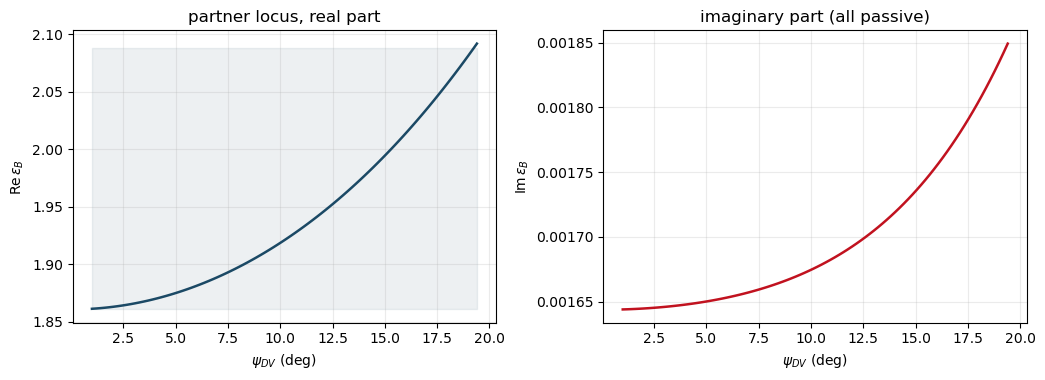

In [7]:
d = 1e-2
et, ez = bruggeman(EPS_A*(1+1j*d), EPS_B_HOST, FA_STAR, SHAPE, kwA=KWA, n=160)
es, etA = et, ez
print(f"HCM at fA={FA_STAR}, delta={d}:  eps_s = {es:.5f},  eps_t^A = {etA:.5f}")
print(f"lossless-analog window for Re eps_B: ({es.real:.3f}, {(etA.real-es.real)/2:.3f})")

pdegs = np.linspace(1.0, 19.4, 90)
locus = np.array([min(eB_partner_locus(es, etA, np.radians(p)), key=lambda r: abs(r.real-1.95))
                  for p in pdegs])
adm = np.array([dv_point(es, etA, e, np.radians(p))['ok'] and e.imag >= 0
                for e, p in zip(locus, pdegs)])
print(f"admissible everywhere on the locus: {adm.all()}")

fig, axs = plt.subplots(1, 2, figsize=(10.5, 3.9))
axs[0].plot(pdegs, locus.real, color="#1b4965", lw=1.8)
axs[0].fill_between(pdegs, es.real, (etA.real-es.real)/2, color="#1b4965", alpha=0.08)
axs[0].set_xlabel(r"$\psi_{DV}$ (deg)"); axs[0].set_ylabel(r"Re$\,\epsilon_B$"); axs[0].set_title("partner locus, real part")
axs[1].plot(pdegs, locus.imag, color="#c1121f", lw=1.8)
axs[1].set_xlabel(r"$\psi_{DV}$ (deg)"); axs[1].set_ylabel(r"Im$\,\epsilon_B$"); axs[1].set_title("imaginary part (all passive)")
for a in axs: a.grid(alpha=0.25)
plt.tight_layout(); plt.show()

eps_B = 1.94487+0.00169j
q/k0  = 1.394626+0.000616j  ->  propagation length 129 wavelengths
alpha_A (double) = -0.00013+0.28996j   [|a1-a2| = 1.4e-15]
alpha_B          = 0.00119-0.01053j
e-folding depths: 0.55 lam0 (composite side), 15.11 lam0 (partner side)
closed-form check: psi_DV = 12.000000 deg, Im = -9.8e-15 deg


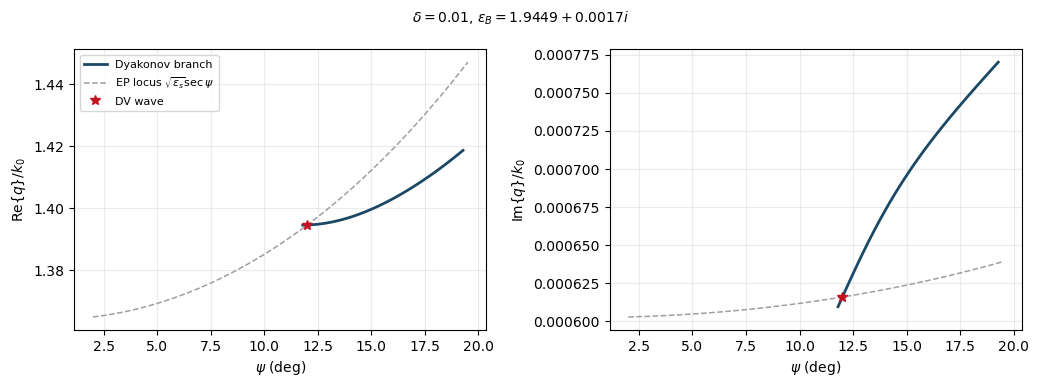

In [8]:
# ---- design point: pick psi* = 12 deg on the locus ----
psis = np.radians(12.0)
eBs = min(eB_partner_locus(es, etA, psis), key=lambda r: abs(r.real-1.95))
sol = dv_point(es, etA, eBs, psis)
pchk = psi_DV(es, etA, eBs)
print(f"eps_B = {eBs:.5f}")
print(f"q/k0  = {sol['q']:.6f}  ->  propagation length {1/(2*sol['q'].imag)/(2*np.pi):.0f} wavelengths")
print(f"alpha_A (double) = {sol['a1']:.5f}   [|a1-a2| = {abs(sol['a1']-sol['a2']):.1e}]")
print(f"alpha_B          = {sol['aB']:.5f}")
print(f"e-folding depths: {1/(2*np.pi*sol['a1'].imag):.2f} lam0 (composite side), "
      f"{1/(2*np.pi*abs(sol['aB'].imag)):.2f} lam0 (partner side)")
print(f"closed-form check: psi_DV = {np.degrees(pchk.real):.6f} deg, Im = {np.degrees(pchk.imag):+.1e} deg")

# ---- Fig.2-style dispersion plot: complex-q Dyakonov branch + DV star ----
pg = np.radians(np.linspace(2, 19.5, 160))
qb = dyakonov_branch(pg, es, etA, eBs, sol['q'], psis)
good = np.isfinite(qb.real)
fig, axs = plt.subplots(1, 2, figsize=(10.5, 3.9))
axs[0].plot(np.degrees(pg[good]), qb[good].real, color="#1b4965", lw=2, label="Dyakonov branch")
axs[0].plot(np.degrees(pg), [q_locus(p, es).real for p in pg], "--", color="#9aa0a6", lw=1.1,
            label=r"EP locus $\sqrt{\epsilon_s}\sec\psi$")
axs[0].plot([12], [sol['q'].real], "*", ms=7, color="#c1121f", zorder=5, label="DV wave")
axs[0].set_xlabel(r"$\psi$ (deg)"); axs[0].set_ylabel(r"Re$\{q\}/k_0$"); axs[0].legend(fontsize=8)
axs[1].plot(np.degrees(pg[good]), qb[good].imag, color="#1b4965", lw=2)
axs[1].plot(np.degrees(pg), [q_locus(p, es).imag for p in pg], "--", color="#9aa0a6", lw=1.1)
axs[1].plot([12], [sol['q'].imag], "*", ms=7, color="#c1121f", zorder=5)
axs[1].set_xlabel(r"$\psi$ (deg)"); axs[1].set_ylabel(r"Im$\{q\}/k_0$")
for a in axs: a.grid(alpha=0.25)
plt.suptitle(fr"$\delta = {d}$, $\epsilon_B = {eBs.real:.4f}+{eBs.imag:.4f}i$", fontsize=10)
plt.tight_layout(); plt.show()